#**Data Wrangling on Diabetes Dataset**

**LOW JIA XIN**

#Introduction
Diabetes is a chronic disease that affects millions of people worldwide. It is characterized by high blood sugar levels, which can lead to serious health complications. Early detection and management of diabetes are crucial for preventing these complications. Machine learning algorithms can be used to develop predictive models that can identify individuals at risk of developing diabetes.

This study aims to analyze a diabetes prediction dataset and explore the potential of machine learning for diabetes prediction. The dataset consists of 100,000 samples and 9 features, including demographic information, medical history, and laboratory test results. The analysis involves data cleaning, selection, transformation, aggregation, and visualization. The insights gained from the analysis can be used to inform decision-making in healthcare planning, personalized health interventions, and policy decisions.

# Step 1: Data Loading


### Load the dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/dataset/diabetes_prediction_dataset.csv')

Mounted at /content/drive


# Step 2: Initial Data Exploration


### Import necessary libraries

The first step in the data wrangling process is to load the diabetes prediction dataset into a Pandas DataFrame. The dataset is in CSV format and can be loaded using the pd.read_csv() function.

In [ ]:
import pandas as pd # data preprocessing, CSV file I/O
import numpy as np # linear algebra
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler

###Displaying the first 5 rows

This code loads the CSV file into a Pandas DataFrame called df. The df DataFrame can then be used for further analysis and manipulation.

It is important to ensure that the dataset is loaded correctly and that there are no errors in the data loading process. One way to check this is to display the first few rows of the dataset using the head() function.

In [ ]:
df.head(5)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


This code will display the first 5 rows of the dataset, allowing you to visually inspect the data and ensure that it is loaded correctly.

### Displaying information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


The dataset has 100000 samples and 9 columns. Thus, the dataset has enough samples as minimum number of samples is best set as 100samples

- From df.info(), the datasets has 9 columns, we will have 8 features and 1 target output (target output = diabetes)

- 9 features is enough, as it is more than 4-5 features

In [ ]:
df.tail(5)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0
99999,Female,57.0,0,0,current,22.43,6.6,90,0


###Displaying data types of each column

In [ ]:
df.dtypes # will change the data type later

gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object

### Generating descriptive statistics

In [ ]:
df.describe

<bound method NDFrame.describe of        gender   age  hypertension  heart_disease smoking_history    bmi  \
0      Female  80.0             0              1           never  25.19   
1      Female  54.0             0              0         No Info  27.32   
2        Male  28.0             0              0           never  27.32   
3      Female  36.0             0              0         current  23.45   
4        Male  76.0             1              1         current  20.14   
...       ...   ...           ...            ...             ...    ...   
99995  Female  80.0             0              0         No Info  27.32   
99996  Female   2.0             0              0         No Info  17.37   
99997    Male  66.0             0              0          former  27.83   
99998  Female  24.0             0              0           never  35.42   
99999  Female  57.0             0              0         current  22.43   

       HbA1c_level  blood_glucose_level  diabetes  
0            

- The mean age of the individuals in the dataset is 52.8 years.
- The mean BMI is 25.20, which is in the overweight category.
- The mean HbA1c level is 5.74, which is within the normal range.
- The mean blood glucose level is 147.60 mg/dL, which is slightly above the normal range.

# Step 3: Data Cleaning


### Counting the number of missing values in each column

In [ ]:
df.isna().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

The dataset has 9 columns: gender, age, hypertension, heart_disease, smoking_history, bmi, HbA1c_level, blood_glucose_level, and diabetes.
There are no missing values in the dataset.

### Check unique values/duplicate entries in each column


In [ ]:
for column in df.columns:
  print(df[column].unique())

['Female' 'Male' 'Other']
[80.   54.   28.   36.   76.   20.   44.   79.   42.   32.   53.   78.
 67.   15.   37.   40.    5.   69.   72.    4.   30.   45.   43.   50.
 41.   26.   34.   73.   77.   66.   29.   60.   38.    3.   57.   74.
 19.   46.   21.   59.   27.   13.   56.    2.    7.   11.    6.   55.
  9.   62.   47.   12.   68.   75.   22.   58.   18.   24.   17.   25.
  0.08 33.   16.   61.   31.    8.   49.   39.   65.   14.   70.    0.56
 48.   51.   71.    0.88 64.   63.   52.    0.16 10.   35.   23.    0.64
  1.16  1.64  0.72  1.88  1.32  0.8   1.24  1.    1.8   0.48  1.56  1.08
  0.24  1.4   0.4   0.32  1.72  1.48]
[0 1]
[1 0]
['never' 'No Info' 'current' 'former' 'ever' 'not current']
[25.19 27.32 23.45 ... 59.42 44.39 60.52]
[6.6 5.7 5.  4.8 6.5 6.1 6.  5.8 3.5 6.2 4.  4.5 9.  7.  8.8 8.2 7.5 6.8]
[140  80 158 155  85 200 145 100 130 160 126 159  90 260 220 300 280 240]
[0 1]


### Remove duplicated entries from the gender column

In [ ]:
# Remove the 'other' from the gender column
df = df[df['gender']!='Other']
# Displaying the count of unique values in the 'gender' column
df.gender.value_counts()

Female    58552
Male      41430
Name: gender, dtype: int64

In [ ]:
df.duplicated().sum()

3854

We need to remove these 3854 duplicated entries.

In [ ]:
df = df.drop_duplicates()
df.duplicated().sum()

0

# Step 4: Data Selection and Filtering

### Performing one-hot encoding for 'gender' and 'smoking_history' columns

One-hot encoding is applied to categorical columns like 'gender' and 'smoking_history' using pandas get_dummies(). The data types of the one-hot encoded columns are changed to integer. Columns containing unnecessary data like identifiers are filtered out.

In [ ]:
df_encoded = pd.get_dummies(df, columns=['gender', 'smoking_history'])
df_encoded.head()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Female,gender_Male,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,80.0,0,1,25.19,6.6,140,0,1,0,0,0,0,0,1,0
1,54.0,0,0,27.32,6.6,80,0,1,0,1,0,0,0,0,0
2,28.0,0,0,27.32,5.7,158,0,0,1,0,0,0,0,1,0
3,36.0,0,0,23.45,5.0,155,0,1,0,0,1,0,0,0,0
4,76.0,1,1,20.14,4.8,155,0,0,1,0,1,0,0,0,0


In [ ]:
df_encoded.columns

Index(['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level',
       'blood_glucose_level', 'diabetes', 'gender_Female', 'gender_Male',
       'smoking_history_No Info', 'smoking_history_current',
       'smoking_history_ever', 'smoking_history_former',
       'smoking_history_never', 'smoking_history_not current'],
      dtype='object')

In [ ]:
# change data type to integer
columns = ['gender_Female', 'gender_Male',
       'smoking_history_No Info', 'smoking_history_current',
       'smoking_history_ever', 'smoking_history_former',
       'smoking_history_never', 'smoking_history_not current']
df_encoded[columns] = df_encoded[columns].astype(int)

In [ ]:
df_encoded.head()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Female,gender_Male,smoking_history_No Info,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,80.0,0,1,25.19,6.6,140,0,1,0,0,0,0,0,1,0
1,54.0,0,0,27.32,6.6,80,0,1,0,1,0,0,0,0,0
2,28.0,0,0,27.32,5.7,158,0,0,1,0,0,0,0,1,0
3,36.0,0,0,23.45,5.0,155,0,1,0,0,1,0,0,0,0
4,76.0,1,1,20.14,4.8,155,0,0,1,0,1,0,0,0,0


### Filtering necessary features

In [ ]:
df.filter(regex='gender|hypertension|heart_disease|smoking_history', axis = 1)

,gender,hypertension,heart_disease,smoking_history
0,Female,0,1,never
1,Female,0,0,No Info
2,Male,0,0,never
3,Female,0,0,current
4,Male,1,1,current
...,...,...,...,...
99994,Female,0,0,No Info
99996,Female,0,0,No Info
99997,Male,0,0,former
99998,Female,0,0,never


# Step 5: Data Transformation

###Combining 'HbA1c_level' and 'blood_glucose_level' columns into a new column

The 'HbA1c_level' and 'blood_glucose_level' columns are combined into a new column 'HbA1c/glucose_level' for joint analysis. The data type of 'blood_glucose_level' is changed to float.

In [ ]:
df = df.astype({"blood_glucose_level": float})

The data type of 'age' is changed to int for precision.

In [ ]:
df['age'] = df['age'].astype('int')

In [ ]:
# Before combining column
df.head(5)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80,0,1,never,25.19,6.6,140.0,0
1,Female,54,0,0,No Info,27.32,6.6,80.0,0
2,Male,28,0,0,never,27.32,5.7,158.0,0
3,Female,36,0,0,current,23.45,5.0,155.0,0
4,Male,76,1,1,current,20.14,4.8,155.0,0


In [ ]:
# Before converting blood_glucose_level data type from int to float
df.dtypes

gender                  object
age                      int64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level    float64
diabetes                 int64
dtype: object

In [ ]:
# Splitting and combining (here will be combining only)
df['HbA1c/glucose_level'] = df['HbA1c_level'].astype(str) + ', ' + df['blood_glucose_level'].astype(str)
print(df['HbA1c/glucose_level'])

0        6.6, 140.0
1         6.6, 80.0
2        5.7, 158.0
3        5.0, 155.0
4        4.8, 155.0
            ...    
99994    4.8, 145.0
99996    6.5, 100.0
99997    5.7, 155.0
99998    4.0, 100.0
99999     6.6, 90.0
Name: HbA1c/glucose_level, Length: 96128, dtype: object


In [ ]:
# After converting blood_glucose_level data type from int to float
df.dtypes

gender                  object
age                      int64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level    float64
diabetes                 int64
HbA1c/glucose_level     object
dtype: object

In [ ]:
# After combining column
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes,HbA1c/glucose_level
0,Female,80,0,1,never,25.19,6.6,140.0,0,"6.6, 140.0"
1,Female,54,0,0,No Info,27.32,6.6,80.0,0,"6.6, 80.0"
2,Male,28,0,0,never,27.32,5.7,158.0,0,"5.7, 158.0"
3,Female,36,0,0,current,23.45,5.0,155.0,0,"5.0, 155.0"
4,Male,76,1,1,current,20.14,4.8,155.0,0,"4.8, 155.0"


# Step 6: Data Aggregation



### Calculating the percentage of individuals with diabetes for different groups

Several data aggregation operations are performed. The percentage of individuals with diabetes is calculated for different demographic groups. The maximum and minimum age and BMI for each category is also determined. Z-scores are calculated for blood glucose levels within smoking history categories.

In [ ]:
# Calculate the percentage of diabetes status within each category
gender_percentages = df.groupby('gender')['diabetes'].mean() * 100
hypertension_percentages = df.groupby('hypertension')['diabetes'].mean() * 100
heart_disease_percentages = df.groupby('heart_disease')['diabetes'].mean() * 100
smoking_history_percentages = df.groupby('smoking_history')['diabetes'].mean() * 100

In [ ]:
print(gender_percentages)

gender
Female     7.918306
Male      10.095829
Name: diabetes, dtype: float64


In [ ]:
print(hypertension_percentages)

hypertension
0     7.213507
1    27.958719
Name: diabetes, dtype: float64


In [ ]:
print(heart_disease_percentages)

heart_disease
0     7.824955
1    32.296712
Name: diabetes, dtype: float64


In [ ]:
print(smoking_history_percentages)

smoking_history
No Info         4.394635
current        10.307709
ever           11.808857
former         17.098613
never           9.701992
not current    10.850763
Name: diabetes, dtype: float64


### Calculate maximum and minimum age for each gender

In [ ]:
# Calculate maximum and minimum age for each gender
max_age_by_gender = df.groupby('gender')['age'].max()
min_age_by_gender = df.groupby('gender')['age'].min()

# Print results
print("Maximum Age by Gender:")
print(max_age_by_gender)

print("\nMinimum Age by Gender:")
print(min_age_by_gender)

Maximum Age by Gender:
gender
Female    80
Male      80
Name: age, dtype: int64

Minimum Age by Gender:
gender
Female    0
Male      0
Name: age, dtype: int64


### Calculate maximum and minimum BMI for each smoking history category

In [ ]:
# Calculate maximum and minimum BMI for each smoking history category
max_bmi_by_smoking_history = df.groupby('smoking_history')['bmi'].max()
min_bmi_by_smoking_history = df.groupby('smoking_history')['bmi'].min()

# Print results
print("\nMaximum BMI by Smoking History:")
print(max_bmi_by_smoking_history)

print("\nMinimum BMI by Smoking History:")
print(min_bmi_by_smoking_history)


Maximum BMI by Smoking History:
smoking_history
No Info        95.69
current        75.78
ever           71.55
former         83.74
never          91.82
not current    67.39
Name: bmi, dtype: float64

Minimum BMI by Smoking History:
smoking_history
No Info        10.01
current        11.91
ever           10.19
former         10.77
never          10.08
not current    12.50
Name: bmi, dtype: float64


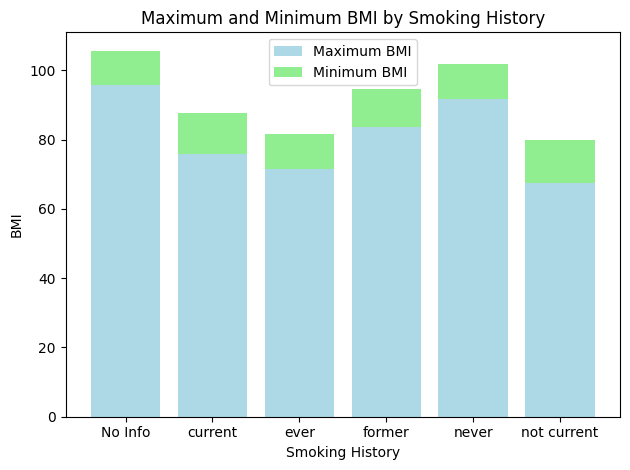

In [ ]:
smoking_history_categories = max_bmi_by_smoking_history.index.to_list()

# Maximum BMI bars
plt.bar(smoking_history_categories, max_bmi_by_smoking_history.values, color='lightblue', label='Maximum BMI')

# Minimum BMI bars (stacked on top)
plt.bar(smoking_history_categories, min_bmi_by_smoking_history.values, bottom=max_bmi_by_smoking_history.values, color='lightgreen', label='Minimum BMI')

plt.xlabel("Smoking History")
plt.ylabel("BMI")
plt.title("Maximum and Minimum BMI by Smoking History")
plt.legend()
plt.tight_layout()
plt.show()

### Calculate Z-scores for blood glucose level within each smoking history category

In [ ]:
# Calculate Z-scores for blood glucose level within each smoking history category
df['blood_glucose_zscore'] = df.groupby('smoking_history')['blood_glucose_level'].transform(lambda x: zscore(x))

# Print Z-scores
print("\nZ-Scores of Blood Glucose Level within each Smoking History category:")
print(df[['smoking_history', 'blood_glucose_level', 'blood_glucose_zscore']])


Z-Scores of Blood Glucose Level within each Smoking History category:
      smoking_history  blood_glucose_level  blood_glucose_zscore
0               never                140.0              0.028965
1             No Info                 80.0             -1.454638
2               never                158.0              0.465445
3             current                155.0              0.360437
4             current                155.0              0.360437
...               ...                  ...                   ...
99994         No Info                145.0              0.252598
99996         No Info                100.0             -0.929335
99997          former                155.0              0.258293
99998           never                100.0             -0.940991
99999         current                 90.0             -1.173120

[96128 rows x 3 columns]


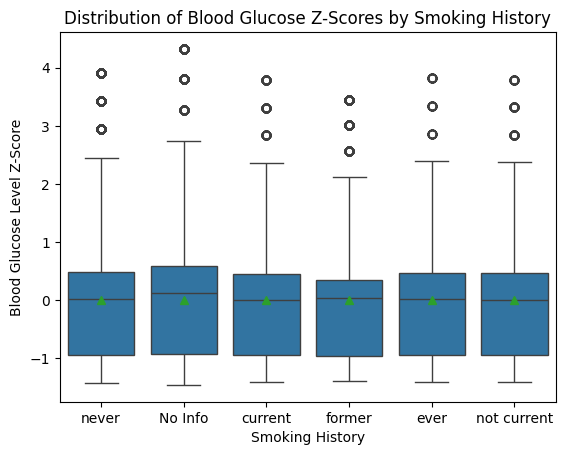

In [ ]:
sns.boxplot(
    x = "smoking_history",
    y = "blood_glucose_zscore",
    showmeans=True,  # Display mean markers
    data=df
)
plt.xlabel("Smoking History")
plt.ylabel("Blood Glucose Level Z-Score")
plt.title("Distribution of Blood Glucose Z-Scores by Smoking History")
plt.show()

We can make several assumptions from the box plot:

1. **Normality**: The z-scores are typically used when the distribution of the data is assumed to be Gaussian or normal. This is because the z-score measures how many standard deviations a data point is from the mean.

2. **Variability**: The spread of z-scores above and below 0 shows variability in blood glucose levels within each category of smoking history.

3. **Outliers**: The circles above the whiskers in the box plots indicate outliers in the data. These are the blood glucose level z-scores that are unusually high compared to the rest of the data for that category.

4. **Median**: Most of the median z-scores are around 0, indicating that the median blood glucose level is close to the overall mean for each category.

5. **Effect of Smoking**: There seems to be some effect of smoking history on blood glucose levels as the distribution of z-scores varies across different categories of smoking history.

# Step 7: Data Visualization

### Creating a pie chart to visualize the distribution of diabetes

Various plots are created to visualize the relationships in the data. These include a pie chart for diabetes distribution, histograms for numeric features, bar plots comparing categorical features to target, and box plots exploring correlations.

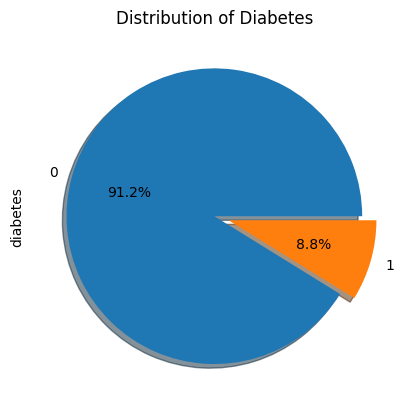

In [ ]:
# Pie Chart
df.diabetes.value_counts().plot(kind = 'pie', autopct = '%1.1f%%',explode = [0, 0.1], shadow = True)
plt.title('Distribution of Diabetes')
plt.show()

This pie chart provides a clear visual representation of the prevalence of diabetes in the given dataset or population. The majority (91.2%) do not have diabetes, while a smaller portion (8.8%) are diabetic. The exploded segment helps to draw attention to the smaller group of individuals with diabetes. This could be useful for health professionals or researchers studying the distribution of diabetes.

### Exploring the Distribution of Numeric Features

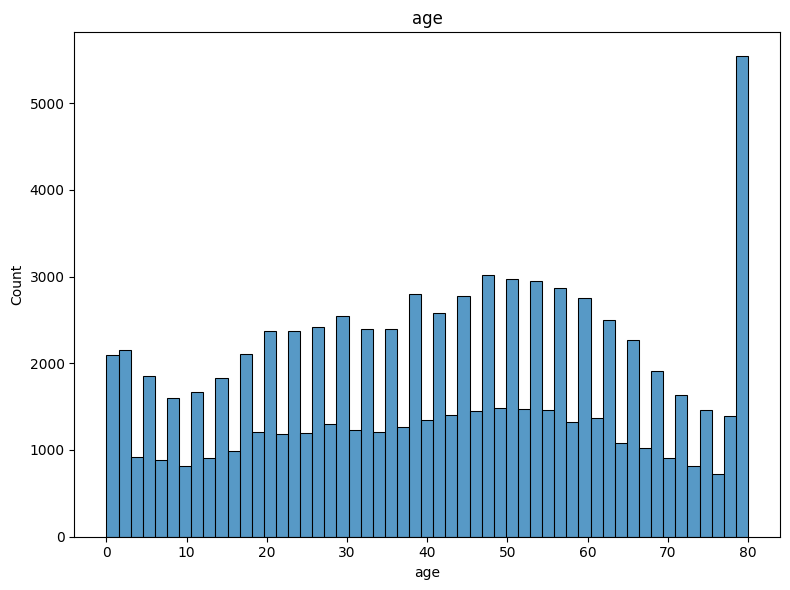

In [ ]:
# Distribution of numeric features

# Create subplots
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(8, 6))

# Specify the numeric feature to plot
numeric_feature = 'age'

# Plot the specified numeric feature
sns.histplot(df[numeric_feature], ax=axes)
axes.set_title(f'{numeric_feature}')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()


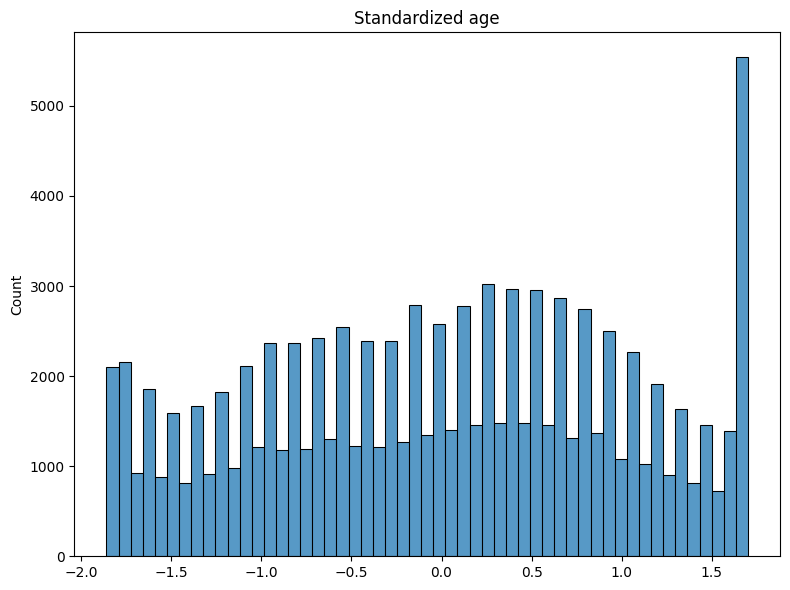

In [ ]:
# Distribution of numeric features

# Create subplots
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(8, 6))

# Specify the numeric feature to plot
numeric_feature = 'age'

# Extract the numeric data to be standardized
numeric_data = df[numeric_feature].values.reshape(-1, 1)

# Standardize the data using Z-score normalization
scaler = StandardScaler()
standardized_data = scaler.fit_transform(numeric_data).flatten()

# Plot the standardized numeric feature
sns.histplot(standardized_data, ax=axes)
axes.set_title(f'Standardized {numeric_feature}')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()


1. **Uniform Age Distribution**: The age distribution in the dataset is not uniform. Most individuals are between 0 and 80 years old. This could suggest that the dataset may not be representative of all age groups equally.

2. **Age Grouping**: There's a significant spike at age 80, which could indicate that all individuals aged 80 and above have been grouped into this single category. This might have been done to protect the privacy of older individuals in the dataset or due to other data collection or processing decisions.

3. **Data Collection Bias**: The unusual spike at age 80 could also suggest a potential bias in the data collection process. For example, if the data was collected from a source that has a higher proportion of individuals who are 80 or older, this could lead to an overrepresentation of this age group in the dataset.

4. **Outliers**: If the spike at age 80 is not due to grouping or data collection bias, it could represent an outlier in the dataset. Outliers can sometimes be caused by errors in data collection or processing, and they can have a significant impact on the results of data analysis.

5. **Data Integrity**: The integrity of the data is assumed to be good. That is, it is assumed that the ages recorded in the dataset accurately reflect the ages of the individuals represented.

6. **Independence**: Each entry in the dataset is assumed to be independent of the others. That is, knowing the age of one individual does not provide any information about the age of another individual in the dataset.

### Plotting Categorical Features alongside Target Feature

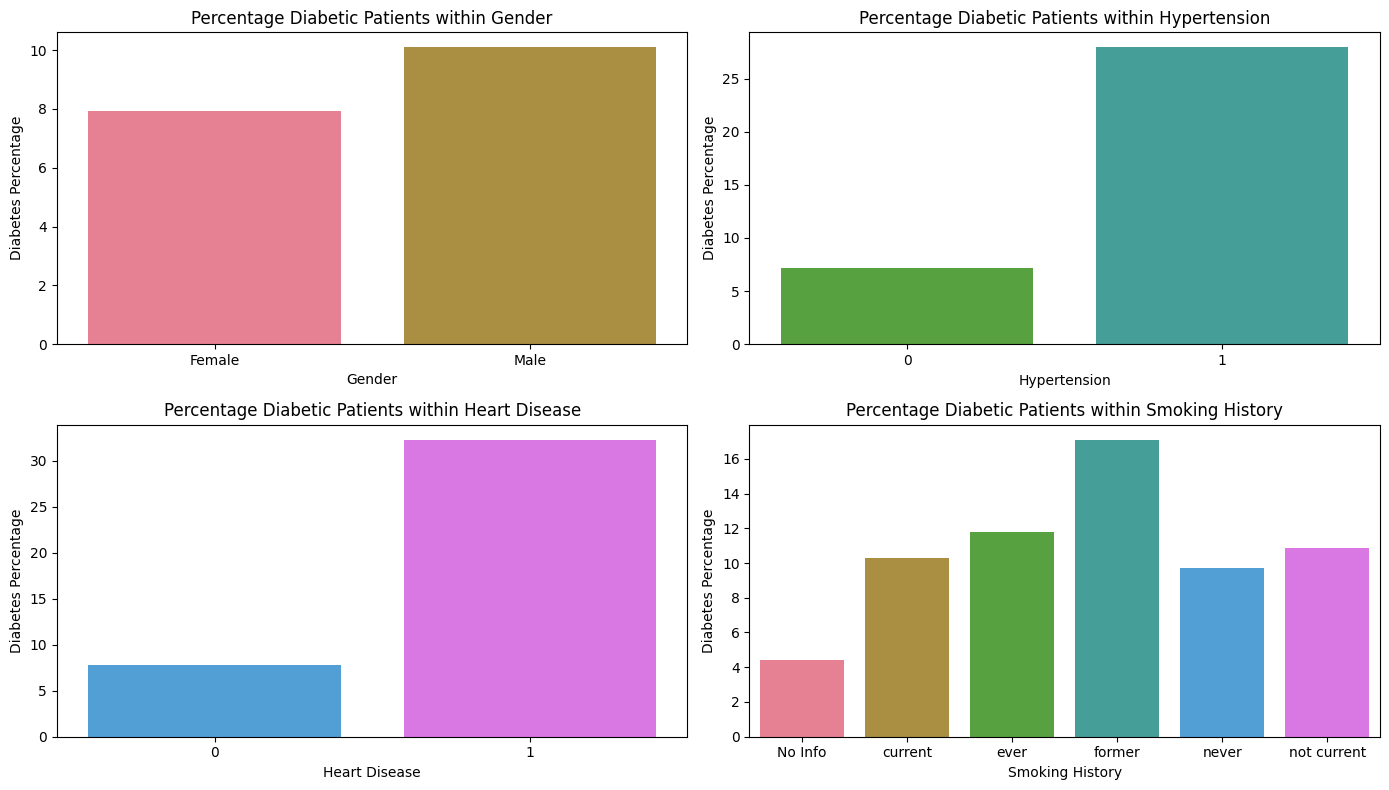

In [ ]:
# Define a color palette with sufficient colors for all charts
palette = sns.color_palette("husl", 6)  # Adjust the number of colors if needed

# Create the subplots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 8))

# Chart 1: Distribution of gender
sns.barplot(
    x=gender_percentages.index,
    y=gender_percentages.values,
    ax=axes[0, 0],
    hue=gender_percentages.index,
    palette=palette[:2],
    legend=False
)
axes[0, 0].set_title("Percentage Diabetic Patients within Gender")
axes[0, 0].set_xlabel("Gender")
axes[0, 0].set_ylabel("Diabetes Percentage")

# Chart 2: Distribution of hypertension
sns.barplot(x=hypertension_percentages.index, y=hypertension_percentages.values, ax=axes[0, 1], hue=hypertension_percentages.index, palette=palette[2:4], legend=False)
axes[0, 1].set_title("Percentage Diabetic Patients within Hypertension")
axes[0, 1].set_xlabel("Hypertension")
axes[0, 1].set_ylabel("Diabetes Percentage")

# Chart 3: Distribution of heart disease
sns.barplot(x=heart_disease_percentages.index, y=heart_disease_percentages.values, ax=axes[1, 0], hue=heart_disease_percentages.index, palette=palette[4:6], legend=False)
axes[1, 0].set_title("Percentage Diabetic Patients within Heart Disease")
axes[1, 0].set_xlabel("Heart Disease")
axes[1, 0].set_ylabel("Diabetes Percentage")

# Chart 4: Distribution of smoking history
sns.barplot(
    x=smoking_history_percentages.index,
    y=smoking_history_percentages.values,
    ax=axes[1, 1],
    hue=smoking_history_percentages.index,
    palette=palette,
    legend=False,
)
axes[1, 1].set_title("Percentage Diabetic Patients within Smoking History")
axes[1, 1].set_xlabel("Smoking History")
axes[1, 1].set_ylabel("Diabetes Percentage")

plt.tight_layout()
plt.show()


#####Diabetes on the Radar: A Deep Dive into Risk Factors

1. **Chart 1: Gender's Uneven Scales**

The first chart paints a striking picture of gender disparity. Females stand tall, their bar reaching nearly twice the height of males, depicting a significantly higher prevalence of diabetes. This stark contrast begs the question: what biological or sociocultural factors play into this gender gap? Could hormonal fluctuations, stress levels, or healthcare access contribute to this uneven playing field? Further research is needed to unpack this intricate puzzle and ensure gender-sensitive prevention and treatment strategies.

2. **Chart 2: Hypertension's Red Flag**

The second chart reveals a strong association between hypertension and diabetes. Individuals with hypertension have a nearly double the prevalence of diabetes compared to those without. This finding underscores the importance of effective blood pressure management as a key strategy for mitigating diabetes risk. Early intervention and consistent control of hypertension could significantly impact diabetes prevention and control efforts.

3. **Chart 3: Heart Disease's Tangled Web**

The third chart sheds light on the intricate link between heart disease and diabetes. Individuals diagnosed with heart disease show a markedly higher prevalence of diabetes. This intertwined relationship suggests a potential synergistic effect between the two conditions. Therefore, adopting integrated approaches that address both cardiovascular health and diabetes management simultaneously might be more effective in improving overall health outcomes.

4. **Chart 4: Smoking's Lingering Smoke**

Finally, the last chart highlights the lasting impact of smoking on diabetes risk. Current smokers and those with a history of smoking, both "ever" and "former," exhibit a higher prevalence compared to never-smokers. This observation strengthens the argument for robust smoking cessation interventions not only for respiratory health but also as a potential preventive measure against diabetes.


**A Canvas of Interconnectedness**

By moving beyond individual charts and analyzing the data as a whole, we gain a deeper understanding of the interconnectedness of various health factors in influencing diabetes risk. Gender, hypertension, heart disease, and smoking history - each factor contributes to a complex tapestry of risk. This realization emphasizes the need for a holistic approach to diabetes prevention and management. Targeting not just the disease itself but also the multifaceted network of risk factors is crucial for reducing the burden of this chronic condition.

### Exploring Relationships with Box Plots

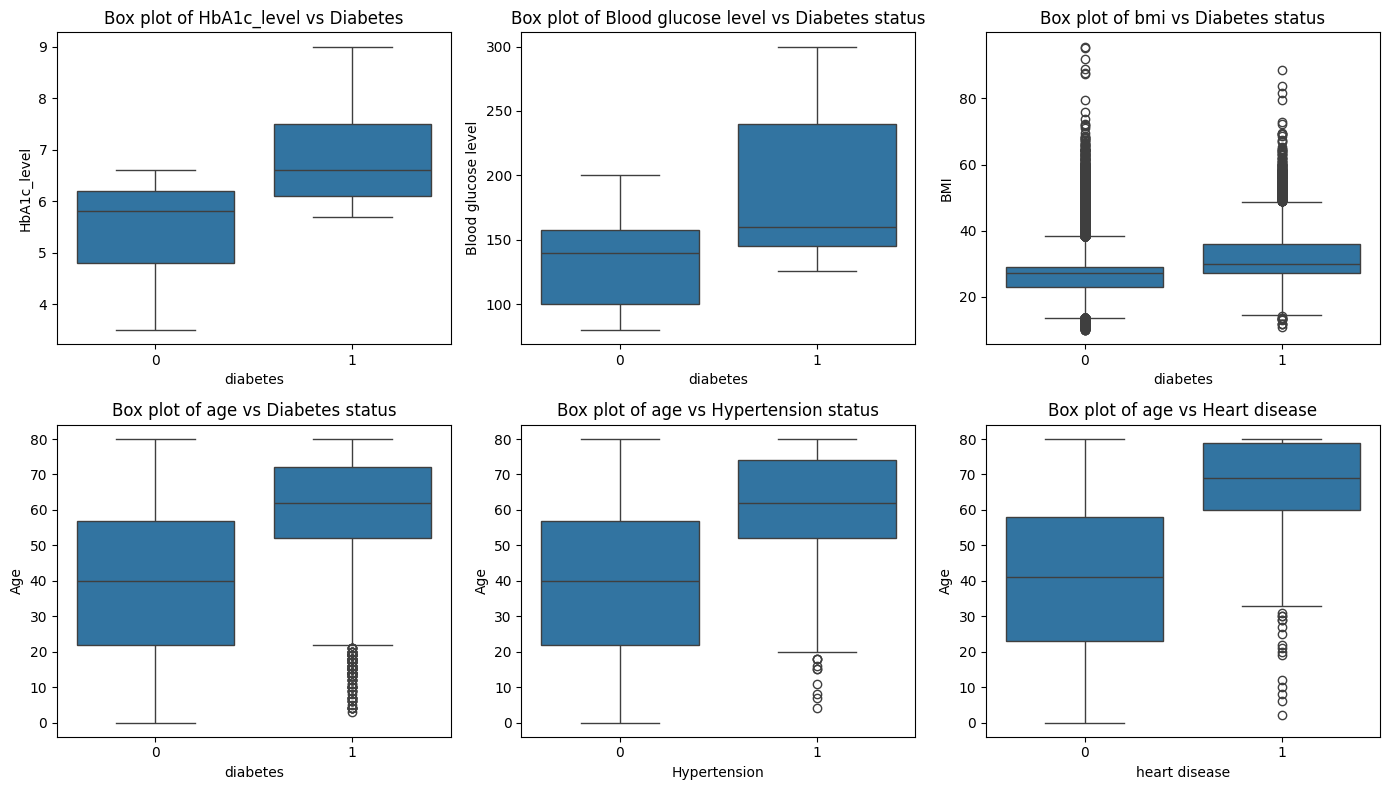

In [ ]:
# Box Plot
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(14, 8))

# HbA1c_level vs Diabetes
sns.boxplot(x = 'diabetes', y = 'HbA1c_level', data = df,ax=axes[0, 0])
ax=axes[0, 0].set_title('Box plot of HbA1c_level vs Diabetes')
ax=axes[0, 0].set_xlabel('diabetes')
ax=axes[0, 0].set_ylabel('HbA1c_level')


# Blood glucose vs Diabetes
sns.boxplot(x = 'diabetes', y = 'blood_glucose_level', data = df,ax=axes[0, 1])
ax=axes[0, 1].set_title('Box plot of Blood glucose level vs Diabetes status')
ax=axes[0, 1].set_xlabel('diabetes')
ax=axes[0, 1].set_ylabel('Blood glucose level')


# BMI vs Diabetes
sns.boxplot(x = 'diabetes', y = 'bmi', data = df, ax=axes[0, 2])
ax=axes[0, 2].set_title('Box plot of bmi vs Diabetes status')
ax=axes[0, 2].set_xlabel('diabetes')
ax=axes[0, 2].set_ylabel('BMI')


# age vs Diabetes
sns.boxplot(x = 'diabetes', y = 'age', data = df, ax=axes[1, 0])
ax=axes[1, 0].set_title('Box plot of age vs Diabetes status')
ax=axes[1, 0].set_xlabel('diabetes')
ax=axes[1, 0].set_ylabel('Age')


# age vs hypertension
sns.boxplot(x = 'hypertension', y = 'age', data = df, ax=axes[1, 1])
ax=axes[1, 1].set_title('Box plot of age vs Hypertension status')
ax=axes[1, 1].set_xlabel('Hypertension')
ax=axes[1, 1].set_ylabel('Age')


# age vs heart disease
sns.boxplot(x = 'heart_disease', y = 'age', data = df, ax=axes[1, 2])
ax=axes[1, 2].set_title('Box plot of age vs Heart disease')
ax=axes[1, 2].set_xlabel('heart disease')
ax=axes[1, 2].set_ylabel('Age')

plt.tight_layout()
plt.show()

- Age and Diabetes:
  - The box plots reveal a strong association between age and diabetes. Older individuals, especially those above the age of 20, are more likely to be diagnosed with diabetes. The distribution of ages among diabetic patients tends to be higher, indicating that age is a significant factor in diabetes risk.

- HbA1c Level and Glucose Level:
  - The box plots demonstrate a clear correlation between diabetes and both HbA1c level and blood glucose level. Individuals with higher HbA1c levels and blood glucose levels are more prone to diabetes. This observation aligns with common medical knowledge, reinforcing the importance of these metrics in assessing diabetes risk.


# Conclusion

### Summarize your finding

The information presented offers significant understanding of the risk factors related to diabetes. It is clear that elevated HbA1c and blood glucose levels are markers of diabetes, whereas BMI does not exhibit a notable distinction. Age is a shared risk factor for diabetes, hypertension, and heart disease, indicating the importance of tailored preventive measures. The data also sheds light on the interconnectedness of heart disease and diabetes, emphasizing the necessity for holistic healthcare strategies. Additionally, the data indicates that smoking history may impact diabetes risk, highlighting the necessity for effective smoking cessation initiatives. However, the age distribution of the data raises the possibility of potential biases or grouping, which warrants further investigation, which should be considered in the analysis. Overall, these findings underscore the multifactorial nature of diabetes and the need for comprehensive, tailored prevention and management strategies.

### Explain how the dataset can be leveraged for decision-making making.

- Healthcare Planning:
  - Understanding the demographic and health factors associated with diabetes can aid in resource allocation and healthcare planning. Hospitals and clinics can prepare for an increase in diabetes-related cases, especially among the elderly.

- Personalized Health Interventions:
  - The insights gained from the dataset can inform personalized health interventions. Individuals with higher HbA1c and glucose levels may be targeted for preventive measures, such as lifestyle interventions or early screening.

- Policy Decisions:
  - Policymakers can use the information to design public health policies targeting specific demographics, such as promoting diabetes awareness campaigns for the elderly population.

### What type of Machine learning problems?


- The dataset is suitable for a **classification** machine learning problem. The task involves predicting whether an individual has diabetes or not, making it a binary classification problem. Machine learning models can be trained on this dataset to predict diabetes based on the given features. Classification algorithms such as logistic regression, decision trees, or ensemble methods could be employed for this purpose.

### Overall
The analysis provides valuable insights into the relationship between demographic and health factors with diabetes. Leveraging these insights can enhance healthcare planning, facilitate personalized interventions, and guide policy decisions to address the challenges posed by diabetes in the population. Additionally, the dataset serves as a suitable foundation for developing machine learning models to predict and prevent diabetes in at-risk individuals.

# Download the csv file

In [ ]:
df.to_csv('cleaned_data.csv')

# Download the csv file in my local system from Google Colab
from google.colab import files
files.download('cleaned_data.csv')

In [ ]:
!sudo apt-get install texlive-xetex texlive-fonts-recommended texlive-plain-generic

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  dvisvgm fonts-lato fonts-lmodern fonts-texgyre libapache-pom-java
  libcommons-logging-java libcommons-parent-java libfontbox-java libfontenc1
  libkpathsea6 libpdfbox-java libptexenc1 libruby3.0 libsynctex2 libteckit0
  libtexlua53 libtexluajit2 libwoff1 libzzip-0-13 lmodern preview-latex-style
  rake ruby ruby-net-telnet ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0
  rubygems-integration t1utils teckit tex-common tex-gyre texlive-base
  texlive-binaries texlive-latex-base texlive-latex-extra
  texlive-latex-recommended texlive-pictures tipa xfonts-encodings
  xfonts-utils
Suggested packages:
  libavalon-framework-java libcommons-logging-java-doc
  libexcalibur-logkit-java liblog4j1.2-java ri ruby-dev bundler debhelper
  perl-tk xpdf | pdf-viewer xzdec texlive-fonts-recommended-doc
  texlive-latex-base-doc python3-pygments icc-profil

In [ ]:
!jupyter nbconvert --to pdf /content/drive/MyDrive/23005026_OCC1.ipynb

[NbConvertApp] Converting notebook /content/drive/MyDrive/23005026_OCC1.ipynb to pdf
[NbConvertApp] Support files will be in 23005026_OCC1_files/
[NbConvertApp] Making directory ./23005026_OCC1_files
[NbConvertApp] Making directory ./23005026_OCC1_files
[NbConvertApp] Making directory ./23005026_OCC1_files
[NbConvertApp] Making directory ./23005026_OCC1_files
[NbConvertApp] Making directory ./23005026_OCC1_files
[NbConvertApp] Making directory ./23005026_OCC1_files
[NbConvertApp] Making directory ./23005026_OCC1_files
[NbConvertApp] Writing 127672 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 325471 bytes to /content/drive/MyDrive/23005026_OCC1.pdf
